# Mini Project 1

## Research Question

Is there a relationship between educational attainment and household income across U.S. counties?

## Data Source

I plan to use publicly available data from the U.S. Census Bureau, including county-level data on educational attainment and median household income.

## Approach

I will collect county-level data and compare the percentage of adults with a bachelor's degree or higher with median household income. I will analyze the relationship between these variables and compare patterns across different counties.

## Goal

The goal is to determine whether counties with higher levels of educational attainment tend to have higher household incomes and identify any notable differences or patterns in the data.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = "e4d3359fb570a2074b7a99e48db688cb01c2e6b8"

url = "https://api.census.gov/data/2024/acs/acs5/profile"

params = {
    "get": "NAME,DP02_0068PE,DP03_0062E",
    "for": "county:*",
    "in": "state:*",
    "key": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data[1:], columns=data[0])

df = df.rename(columns={
    "NAME": "County",
    "DP02_0068PE": "Education",
    "DP03_0062E": "Median_Income"
})

df.head()

,County,Education,Median_Income,state,county
0,"Autauga County, Alabama",29.1,72481,01,001
1,"Baldwin County, Alabama",33.7,78775,01,003
2,"Barbour County, Alabama",10.6,46042,01,005
3,"Bibb County, Alabama",11.7,52541,01,007
4,"Blount County, Alabama",15.8,64190,01,009


In [2]:
df["Education"] = pd.to_numeric(df["Education"], errors="coerce")
df["Median_Income"] = pd.to_numeric(df["Median_Income"], errors="coerce")

In [ ]:
df.loc[df["Median_Income"] < 0, "Median_Income"] = pd.NA
df.loc[df["Education"] < 0, "Education"] = pd.NA

df_clean = df.dropna(subset=["Education", "Median_Income"])

df_clean[["Education", "Median_Income"]].describe()

,Education,Median_Income
count,3143.000000,3143.000000
mean,24.690169,67976.429208
std,10.285981,17774.483025
min,0.000000,22188.000000
25%,17.500000,56728.000000
50%,22.200000,65681.000000
75%,29.600000,75827.000000
max,80.500000,181765.000000


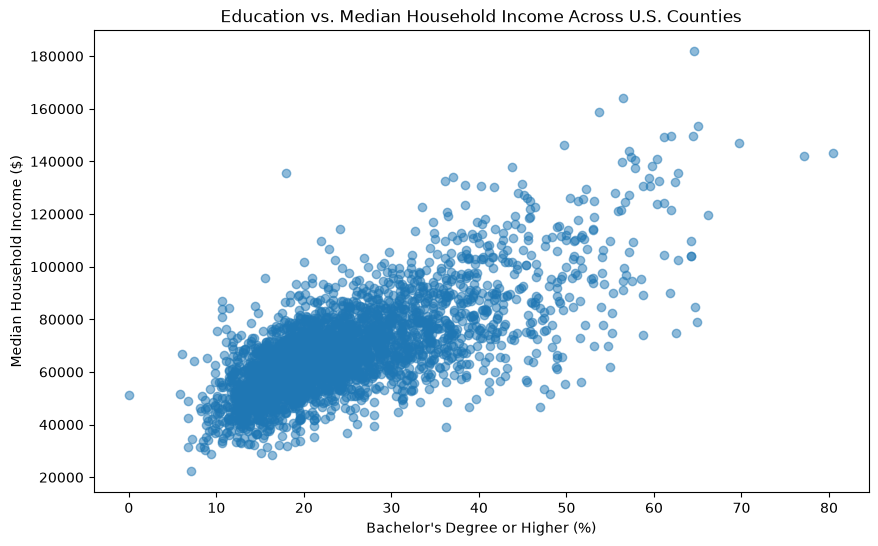

In [4]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["Education"],
    df_clean["Median_Income"],
    alpha=0.5
)

plt.xlabel("Bachelor's Degree or Higher (%)")
plt.ylabel("Median Household Income ($)")
plt.title("Education vs. Median Household Income Across U.S. Counties")

plt.show()

In [5]:
correlation = df_clean["Education"].corr(df_clean["Median_Income"])
print("Correlation:", correlation)

Correlation: 0.7197267078866157


In [6]:
df_clean.nlargest(10, "Education")[
    ["County", "Education", "Median_Income"]
]

,County,Education,Median_Income
2927,"Falls Church city, Virginia",80.5,143262.0
2828,"Arlington County, Virginia",77.1,142114.0
1812,"Los Alamos County, New Mexico",69.7,147139.0
2917,"Alexandria city, Virginia",66.2,119681.0
2850,"Fairfax County, Virginia",65.0,153637.0
302,"San Miguel County, Colorado",64.9,79024.0
271,"Gunnison County, Colorado",64.7,84527.0
2874,"Loudoun County, Virginia",64.6,181765.0
1207,"Howard County, Maryland",64.5,149763.0
251,"Boulder County, Colorado",64.2,103994.0


In [7]:
df_clean.nlargest(10, "Median_Income")[
    ["County", "Education", "Median_Income"]
]

,County,Education,Median_Income
2874,"Loudoun County, Virginia",64.6,181765.0
229,"Santa Clara County, California",56.5,164281.0
227,"San Mateo County, California",53.7,158855.0
2850,"Fairfax County, Virginia",65.0,153637.0
1207,"Howard County, Maryland",64.5,149763.0
263,"Douglas County, Colorado",62.0,149594.0
207,"Marin County, California",61.1,149091.0
1812,"Los Alamos County, New Mexico",69.7,147139.0
1859,"Nassau County, New York",49.7,146202.0
446,"Forsyth County, Georgia",57.1,143784.0


In [8]:
df_clean.nsmallest(10, "Education")[
    ["County", "Education", "Median_Income"]
]

,County,Education,Median_Income
2675,"Loving County, Texas",0.0,51250.0
83,"Kusilvak Census Area, Alaska",5.8,51471.0
1761,"Pershing County, Nevada",6.1,66902.0
2590,"Duval County, Texas",6.8,49038.0
2700,"Newton County, Texas",6.8,42618.0
3017,"McDowell County, West Virginia",6.8,31559.0
1089,"Owsley County, Kentucky",7.1,22188.0
150,"Lee County, Arkansas",7.2,34375.0
2719,"Reeves County, Texas",7.4,64297.0
5,"Bullock County, Alabama",8.1,31310.0
